# EEA Air Quality - Download, Analysis & Comparison
### Pollutants: NO₂ | NOX as NO₂ | SO₂ | CO | Unit: µg/m³

| Step | Description |
|------|-------------|
| 0 | Installation |
| 1 | Imports, constants & legal limits |
| 2 | EEA API client (pure `requests`) |
| 3 | Country & period selector |
| 3b | Data cleaning & unit conversion |
| 4 | Dataset overview |
| 5 | Descriptive statistics |
| 6 | Legal limit exceedances |
| 7 | Time series & trend |
| 8 | Country mean comparison |
| 9 | Annual mean by country |
| 10 | Monthly heatmap |
| 11 | Distribution (boxplot) |
| 12 | Pollutant correlation |
| 13 | Choropleth — exceedances by country |
| 14 | Export |

---

> **How data is downloaded and aggregated**
>
> The EEA API (`/ParquetFile`) supports three `aggregationType` values:
> - **`hour`**: one value per hour per station (very large files, not recommended)
> - **`day`**: one daily mean per station *this notebook uses daily*
> - **`variable`**: pre-aggregated at variable intervals (weekly, monthly…) reported by countries
>
> This notebook **always requests daily data** (`aggregationType: day`), which is the best
> balance between detail and file size. Monthly and yearly statistics are then computed
> **locally in Python** by grouping and averaging the daily values, giving you full control
> over the aggregation without crashing your machine.
>
> The EEA API does **not** offer a `month` or `year` aggregation type directly.


# Cell 0 — Installation (first time only)

In [1]:
# !pip install requests pandas pyarrow matplotlib seaborn scipy ipywidgets plotly

# Cell 1 — Imports, constants & legal limits

In [2]:
import os, io, zipfile, warnings, time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.3, 'font.size': 10,
})

EEA_API   = 'https://eeadmz1-downloads-api-appservice.azurewebsites.net/'
OUT_DIR   = 'eea_output'
UNIT      = 'µg/m³'
os.makedirs(OUT_DIR, exist_ok=True)

POLLUTANTS = ['NO2', 'NOX as NO2', 'SO2', 'CO']

COUNTRY_PALETTE = [
    '#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6',
    '#1ABC9C','#E67E22','#34495E','#E91E63','#00BCD4',
    '#8BC34A','#FF5722','#607D8B','#795548','#673AB7',
]

DATASET_IDS = {'Verified': 2, 'Unverified': 1, 'Historical': 3}
DATASET_RANGES = {
    'Verified':   (2013, 2023),
    'Unverified': (2024, 2025),
    'Historical': (2002, 2012),
}

COUNTRY_NAMES = {
    'AD':'Andorra','AL':'Albania','AT':'Austria','BA':'Bosnia','BE':'Belgium',
    'BG':'Bulgaria','CH':'Switzerland','CY':'Cyprus','CZ':'Czechia','DE':'Germany',
    'DK':'Denmark','EE':'Estonia','EL':'Greece','ES':'Spain','FI':'Finland',
    'FR':'France','HR':'Croatia','HU':'Hungary','IE':'Ireland','IS':'Iceland',
    'IT':'Italy','LI':'Liechtenstein','LT':'Lithuania','LU':'Luxembourg','LV':'Latvia',
    'ME':'Montenegro','MK':'North Macedonia','MT':'Malta','NL':'Netherlands',
    'NO':'Norway','PL':'Poland','PT':'Portugal','RO':'Romania','RS':'Serbia',
    'SE':'Sweden','SI':'Slovenia','SK':'Slovakia','TR':'Turkey','XK':'Kosovo',
    'GB':'United Kingdom',
}

# ISO alpha-2 → alpha-3  (needed for choropleth)
ISO2_TO_ISO3 = {
    'AD':'AND','AL':'ALB','AT':'AUT','BA':'BIH','BE':'BEL','BG':'BGR',
    'CH':'CHE','CY':'CYP','CZ':'CZE','DE':'DEU','DK':'DNK','EE':'EST',
    'EL':'GRC','ES':'ESP','FI':'FIN','FR':'FRA','HR':'HRV','HU':'HUN',
    'IE':'IRL','IS':'ISL','IT':'ITA','LI':'LIE','LT':'LTU','LU':'LUX',
    'LV':'LVA','ME':'MNE','MK':'MKD','MT':'MLT','NL':'NLD','NO':'NOR',
    'PL':'POL','PT':'PRT','RO':'ROU','RS':'SRB','SE':'SWE','SI':'SVN',
    'SK':'SVK','TR':'TUR','XK':'XKX','GB':'GBR',
}

STATE = {
    'df':        pd.DataFrame(),
    'countries': [],
    'y0':        2020,
    'y1':        2022,
    'dataset':   'Verified',
}

def country_color_map(countries):
    return {c: COUNTRY_PALETTE[i % len(COUNTRY_PALETTE)]
            for i, c in enumerate(sorted(countries))}

# Legal limits (µg/m³) 
# EU:  Directive 2008/50/EC + 2024/2881 (2030 targets)
# WHO: Air Quality Guidelines 2021
# Sources:
#   EU  → https://environment.ec.europa.eu/topics/air/air-quality/eu-air-quality-standards_en
#   WHO → https://www.who.int/publications/i/item/9789240034228

LIMITS = {
    'NO2': {
        'EU annual (current)': {'value': 40,    'org': 'EU',  'type': 'annual'},
        'EU annual (2030)':    {'value': 20,    'org': 'EU',  'type': 'annual'},
        'EU hourly':           {'value': 200,   'org': 'EU',  'type': 'hourly'},
        'WHO annual':          {'value': 10,    'org': 'WHO', 'type': 'annual'},
    },
    'NOX as NO2': {
        'EU ecosystems':       {'value': 30,    'org': 'EU',  'type': 'annual'},
    },
    'SO2': {
        'EU daily':            {'value': 125,   'org': 'EU',  'type': 'daily'},
        'EU hourly':           {'value': 350,   'org': 'EU',  'type': 'hourly'},
        'WHO daily':           {'value': 40,    'org': 'WHO', 'type': 'daily'},
        'WHO annual':          {'value': 40,    'org': 'WHO', 'type': 'annual'},
    },
    'CO': {
        'EU max 8h':           {'value': 10000, 'org': 'EU',  'type': '8h'},
        'WHO max 8h':          {'value': 4000,  'org': 'WHO', 'type': '8h'},
    },
}

# Annual reference limits for coloring (green / yellow / red)
ANNUAL_LIMITS = {
    'NO2':        {'WHO': 10,   'EU': 40},
    'NOX as NO2': {'WHO': None, 'EU': 30},
    'SO2':        {'WHO': 40,   'EU': 125},
    'CO':         {'WHO': 4000, 'EU': 10000},
}

# Display limits table 
_rows = []
for _poll, _lims in LIMITS.items():
    for _name, _d in _lims.items():
        _rows.append({
            'Pollutant': _poll, 'Limit name': _name,
            f'Value ({UNIT})': _d['value'],
            'Type': _d['type'], 'Organisation': _d['org'],
        })
_ldf = pd.DataFrame(_rows)

display(HTML(
    '<h3>Legal Air Quality Limits</h3>'
    '<p style="font-size:12px">'
    '<b>EU standard:</b> <a href="https://environment.ec.europa.eu/topics/air/'
    'air-quality/eu-air-quality-standards_en" target="_blank">EU Air Quality Standards</a>'
    ' &nbsp;|&nbsp; '
    '<b>WHO guideline:</b> <a href="https://www.who.int/publications/i/item/9789240034228"'
    ' target="_blank">WHO Air Quality Guidelines 2021</a></p>'
    '<p style="font-size:11px;background:#fff3cd;padding:6px 10px;'
    'border-radius:4px;display:inline-block">'
    '🟢 Below WHO &nbsp; 🟡 Between WHO and EU &nbsp; 🔴 Above EU limit</p>'
))
display(_ldf.style
    .applymap(lambda v: 'color:#1565C0;font-weight:bold' if v == 'EU'
              else ('color:#2E7D32;font-weight:bold' if v == 'WHO' else ''),
              subset=['Organisation'])
    .set_properties(**{'text-align': 'center', 'font-size': '10pt', 'padding': '4px 8px'})
    .hide(axis='index')
    .set_caption(f'All values in {UNIT}'))

print('Cell 1 OK | unit:', UNIT)


Pollutant,Limit name,Value (µg/m³),Type,Organisation
NO2,EU annual (current),40,annual,EU
NO2,EU annual (2030),20,annual,EU
NO2,EU hourly,200,hourly,EU
NO2,WHO annual,10,annual,WHO
NOX as NO2,EU ecosystems,30,annual,EU
SO2,EU daily,125,daily,EU
SO2,EU hourly,350,hourly,EU
SO2,WHO daily,40,daily,WHO
SO2,WHO annual,40,annual,WHO
CO,EU max 8h,10000,8h,EU


Cell 1 OK | unit: µg/m³


# Cell 2 — EEA API client

How it works (based on API documentation + diagnostics):

   /ParquetFile      → HTTP 400 "Request too large" for any country-level request.
                       The API itself says: "use the List of URLs format".

   /ParquetFile/urls → Returns a CSV file with direct URLs to individual parquet
                       files (one per sampling point / station).
                       Ignores dateTimeStart, dateTimeEnd and aggregationType.
                       We download each parquet and filter locally by year.

   /ParquetFile/async → Works but requires polling a blob URL; slower.

 Strategy:
   1. POST /ParquetFile/urls  → get CSV of parquet URLs
   2. Parse the CSV, extract the URL column
   3. Download each parquet file individually
   4. Filter rows to the requested year range
   5. Aggregate to daily means (in case parquets contain hourly data)

 The EEA API does not support month/year aggregation directly.
 Monthly and yearly statistics are computed locally from the daily data.

In [3]:
import io, requests, time
import pandas as pd
import numpy as np

EEA_BASE = 'https://eeadmz1-downloads-api-appservice.azurewebsites.net/'

POLL_ID_MAP = {
    '8':'NO2', '38':'NO2',
    '9':'NOX as NO2', '19':'NOX as NO2',
    '1':'SO2',
    '10':'CO',
}

def _clean(df, country, y0, y1):
    '''Normalize columns, parse dates, filter by year range.'''
    cl = {c.lower(): c for c in df.columns}
    dt_col   = next((cl[s] for s in ['start','datetimebegin','datetime','time','starttime'] if s in cl), None)
    val_col  = next((cl[s] for s in ['concentration','value','val','measure'] if s in cl), None)
    poll_col = next((cl[s] for s in ['airpollutant','pollutant','notation','airpollutantcode'] if s in cl), None)
    stn_col  = next((cl[s] for s in ['samplingpoint','samplingpointid','stationcode','station_code','localid'] if s in cl), None)

    rn = {}
    if dt_col:   rn[dt_col]   = 'datetime'
    if val_col:  rn[val_col]  = 'value'
    if poll_col: rn[poll_col] = 'pollutant'
    if stn_col:  rn[stn_col]  = 'station_code'
    for tgt, srcs in {
        'country':   ['country','countrycode','referencecountry'],
        'unit':      ['unit','measurementunit','uom'],
        'latitude':  ['latitude','lat'],
        'longitude': ['longitude','lon'],
    }.items():
        for s in srcs:
            if s in cl and tgt not in rn.values():
                rn[cl[s]] = tgt; break

    df = df.rename(columns=rn)

    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'], utc=True, errors='coerce')
        df['date']  = df['datetime'].dt.date
        df['year']  = df['datetime'].dt.year
        df['month'] = df['datetime'].dt.month

    if 'value' in df.columns:
        df['value'] = pd.to_numeric(df['value'], errors='coerce')

    if 'pollutant' in df.columns:
        def _norm(v):
            v = str(v)
            num = v.split('/')[-1].split('_')[-1] if '/' in v else v
            return POLL_ID_MAP.get(num, v)
        df['pollutant'] = df['pollutant'].apply(_norm).str.strip()
        df = df[df['pollutant'].isin(POLLUTANTS)]

    if 'country' not in df.columns or df['country'].isna().all():
        df['country'] = country
    else:
        df['country'] = df['country'].astype(str).str.strip()

    # Filter by requested year range
    if 'year' in df.columns and y0 and y1:
        df = df[(df['year'] >= y0) & (df['year'] <= y1)]

    # If data is hourly, resample to daily means per station
    if 'datetime' in df.columns and 'station_code' in df.columns and len(df) > 0:
        # Check if sub-daily by seeing if multiple rows share the same date+station+poll
        grp = ['station_code','pollutant','date']
        grp = [c for c in grp if c in df.columns]
        counts = df.groupby(grp).size() if grp else pd.Series([1])
        if counts.max() > 1:
            # Aggregate to daily
            agg_cols = [c for c in ['country','station_code','pollutant','year','month','date'] if c in df.columns]
            df = (df.groupby(agg_cols, dropna=False)['value']
                    .mean().reset_index())
            # Rebuild datetime as date only
            if 'date' in df.columns:
                df['datetime'] = pd.to_datetime(df['date'], utc=True, errors='coerce')

    return df.reset_index(drop=True)


def _get_parquet_urls(country, pollutant, dataset, session):
    '''
    Call /ParquetFile/urls to get a CSV of parquet file URLs.
    Returns list of URL strings, or empty list on failure.
    '''
    body = {
        'countries':  [country],
        'cities':     [],
        'pollutants': [pollutant],
        'dataset':    DATASET_IDS[dataset],
        'source':     'API',
    }
    try:
        r = session.post(EEA_BASE + 'ParquetFile/urls', json=body, timeout=60)
    except Exception as e:
        return [], str(e)

    if r.status_code != 200:
        return [], f'HTTP {r.status_code}'
    if len(r.content) < 10:
        return [], 'Empty response'

    # Response is a CSV file — find the column that contains URLs
    try:
        csv_df = pd.read_csv(io.BytesIO(r.content))
        # URL column is usually named 'url', 'URL', 'link', or contains 'blob'
        url_col = next(
            (c for c in csv_df.columns
             if any(k in c.lower() for k in ['url','link','path','blob'])),
            csv_df.columns[0]  # fallback: first column
        )
        urls = csv_df[url_col].dropna().tolist()
        return urls, None
    except Exception as e:
        # Maybe the CSV has no header — try reading raw lines
        try:
            lines = r.text.strip().splitlines()
            urls  = [l.strip() for l in lines if l.strip().startswith('http')]
            return urls, None if urls else 'No URLs found in response'
        except Exception:
            return [], f'Could not parse CSV: {e}'


def _download_parquet(url, session):
    '''Download a single parquet file from a URL.'''
    try:
        r = session.get(url, timeout=90)
        r.raise_for_status()
        return pd.read_parquet(io.BytesIO(r.content)), None
    except Exception as e:
        return pd.DataFrame(), str(e)


def download_many(countries, y0, y1, dataset='Verified', progress_out=None):
    '''
    For each (country, pollutant):
      1. Get list of parquet URLs from /ParquetFile/urls
      2. Download each parquet individually
      3. Filter locally to y0-y1 range
    Returns (DataFrame, dict_of_errors).
    '''
    session  = requests.Session()
    all_dfs  = []
    errors   = {}
    tasks    = [(c, p) for c in countries for p in POLLUTANTS]
    n_tasks  = len(tasks)

    for i, (ctr, poll) in enumerate(tasks):
        name = COUNTRY_NAMES.get(ctr, ctr)

        if progress_out:
            with progress_out:
                clear_output(wait=True)
                pct = int(i / n_tasks * 100)
                bar = ('=' * (pct // 5)).ljust(20)
                display(HTML(
                    f'<div style="background:#e9ecef;border-radius:6px;'
                    f'padding:10px;font-size:12px">'
                    f'Step 1/2 — Getting file list for '
                    f'<b>{name} ({ctr})</b> | <b>{poll}</b> '
                    f'({i+1}/{n_tasks})<br>'
                    f'<code>[{bar}] {pct}%</code></div>'))

        urls, err = _get_parquet_urls(ctr, poll, dataset, session)

        if err or not urls:
            errors[f'{ctr} {poll}'] = err or 'No URLs returned'
            continue

        if progress_out:
            with progress_out:
                clear_output(wait=True)
                display(HTML(
                    f'<div style="background:#e9ecef;border-radius:6px;'
                    f'padding:10px;font-size:12px">'
                    f'Step 2/2 — Downloading <b>{len(urls)}</b> parquet files for '
                    f'<b>{name}</b> | <b>{poll}</b> '
                    f'({i+1}/{n_tasks})<br>'
                    f'Filtering to {y0}–{y1} locally...</div>'))

        pair_dfs = []
        pair_errs = 0
        for url in urls:
            df_p, err_p = _download_parquet(url, session)
            if not df_p.empty:
                pair_dfs.append(df_p)
            elif err_p:
                pair_errs += 1
            time.sleep(0.05)

        if pair_dfs:
            combined = _clean(pd.concat(pair_dfs, ignore_index=True), ctr, y0, y1)
            if not combined.empty:
                all_dfs.append(combined)
            else:
                errors[f'{ctr} {poll}'] = f'No data in {y0}–{y1} (files cover other years)'
        else:
            errors[f'{ctr} {poll}'] = f'All {len(urls)} parquet downloads failed'

        time.sleep(0.2)

    if not all_dfs:
        return pd.DataFrame(), errors

    result = pd.concat(all_dfs, ignore_index=True)
    key_cols = [c for c in ['datetime','station_code','pollutant'] if c in result.columns]
    if key_cols:
        result = result.drop_duplicates(subset=key_cols)
    return result.sort_values([c for c in ['country','pollutant','datetime'] if c in result.columns]).reset_index(drop=True), errors


def make_demo(countries, y0, y1):
    BASE = {
        'DE':{'NO2':28,'NOX as NO2':45,'SO2':8, 'CO':300},
        'FR':{'NO2':33,'NOX as NO2':52,'SO2':12,'CO':380},
        'IT':{'NO2':38,'NOX as NO2':60,'SO2':18,'CO':450},
        'ES':{'NO2':30,'NOX as NO2':48,'SO2':10,'CO':330},
        'PL':{'NO2':42,'NOX as NO2':68,'SO2':35,'CO':600},
        'NL':{'NO2':25,'NOX as NO2':40,'SO2':7, 'CO':280},
        'BE':{'NO2':35,'NOX as NO2':55,'SO2':11,'CO':360},
        'AT':{'NO2':22,'NOX as NO2':36,'SO2':6, 'CO':250},
        'SE':{'NO2':15,'NOX as NO2':25,'SO2':4, 'CO':200},
        'PT':{'NO2':20,'NOX as NO2':32,'SO2':8, 'CO':270},
        'GB':{'NO2':29,'NOX as NO2':46,'SO2':9, 'CO':320},
        'CH':{'NO2':18,'NOX as NO2':29,'SO2':5, 'CO':220},
        'DK':{'NO2':17,'NOX as NO2':27,'SO2':5, 'CO':210},
        'CZ':{'NO2':36,'NOX as NO2':58,'SO2':28,'CO':520},
        'RO':{'NO2':34,'NOX as NO2':54,'SO2':22,'CO':490},
    }
    np.random.seed(42)
    dates = pd.date_range(f'{y0}-01-01', f'{y1}-12-31', freq='D', tz='UTC')
    rows, n = [], len(dates)
    for ctr in countries:
        base   = BASE.get(ctr, {'NO2':30,'NOX as NO2':48,'SO2':14,'CO':380})
        np.random.seed(hash(ctr) % 9999)
        n_stns = np.random.randint(3, 9)
        stns   = [f'{ctr}_ST{i:02d}' for i in range(1, n_stns+1)]
        for stn in stns:
            for poll, b in base.items():
                np.random.seed(hash(stn+poll) % 9999)
                season   = np.sin(np.linspace(0, 2*np.pi*n/365, n))
                vals     = np.clip(b + b*0.28*season + np.random.normal(0,b*0.18,n), 0, None)
                gap_mask = np.random.rand(n) < 0.05
                for i, d in enumerate(dates):
                    rows.append({
                        'datetime':     d, 'date': d.date(),
                        'year':         d.year, 'month': d.month,
                        'country':      ctr, 'station_code': stn,
                        'pollutant':    poll,
                        'value':        round(float(vals[i]),2) if not gap_mask[i] else np.nan,
                        'unit':         UNIT,
                    })
    return pd.DataFrame(rows)

print('Cell 2 OK | strategy: /ParquetFile/urls → CSV → download parquets → filter locally')


Cell 2 OK | strategy: /ParquetFile/urls → CSV → download parquets → filter locally


In [4]:
# Cell DEBUG — test /ParquetFile/urls CSV parsing
# Run this ONCE to verify the URL strategy works before downloading.

import requests, io, pandas as pd

EEA = 'https://eeadmz1-downloads-api-appservice.azurewebsites.net/'
s   = requests.Session()

body = {
    'countries':  ['IT'],
    'cities':     [],
    'pollutants': ['NO2'],
    'dataset':    2,
    'source':     'API',
}

print("Calling /ParquetFile/urls for Italy NO2 (Verified)...")
r = s.post(EEA + 'ParquetFile/urls', json=body, timeout=60)
print(f"Status : {r.status_code}")
print(f"Content-Type: {r.headers.get('Content-Type')}")
print(f"Size   : {len(r.content):,} bytes")
print()

# Parse as CSV
csv_df = pd.read_csv(io.BytesIO(r.content))
print(f"CSV columns : {list(csv_df.columns)}")
print(f"CSV rows    : {len(csv_df)}")
print()
print("First 3 rows:")
print(csv_df.head(3).to_string())
print()

# Find URL column
url_col = next(
    (c for c in csv_df.columns if any(k in c.lower() for k in ['url','link','path','blob'])),
    csv_df.columns[0])
print(f"URL column identified: '{url_col}'")
urls = csv_df[url_col].dropna().tolist()
print(f"Total URLs  : {len(urls)}")
print(f"Sample URL  : {urls[0] if urls else 'none'}")
print()

# Try downloading the first parquet
if urls:
    print(f"Downloading first parquet: {urls[0][:80]}...")
    r2 = s.get(urls[0], timeout=60)
    print(f"  Status : {r2.status_code}")
    print(f"  Size   : {len(r2.content):,} bytes")
    if r2.status_code == 200:
        df_test = pd.read_parquet(io.BytesIO(r2.content))
        print(f"  Shape  : {df_test.shape}")
        print(f"  Columns: {list(df_test.columns)}")
        print(f"  First row:")
        print(df_test.iloc[0].to_string())


Calling /ParquetFile/urls for Italy NO2 (Verified)...
Status : 200
Content-Type: text/csv
Size   : 94,098 bytes

CSV columns : ['ParquetFileUrl']
CSV rows    : 784

First 3 rows:
                                                                                                            ParquetFileUrl
0  https://eeadmz1batchservice02.blob.core.windows.net/airquality-p-e1a/IT/SPO.IT1598A_8_chemi_2005-01-01_00_00_00.parquet
1  https://eeadmz1batchservice02.blob.core.windows.net/airquality-p-e1a/IT/SPO.IT2164A_8_chemi_2017-01-01_00_00_00.parquet
2  https://eeadmz1batchservice02.blob.core.windows.net/airquality-p-e1a/IT/SPO.IT2282A_8_chemi_2019-01-01_00_00_00.parquet

URL column identified: 'ParquetFileUrl'
Total URLs  : 784
Sample URL  : https://eeadmz1batchservice02.blob.core.windows.net/airquality-p-e1a/IT/SPO.IT1598A_8_chemi_2005-01-01_00_00_00.parquet

  Status : 200
  Size   : 1,789,803 bytes
  Shape  : (105192, 12)
  Columns: ['Samplingpoint', 'Pollutant', 'Start', 'End', 'Value', 'U

# Cell 3 - Country & period selector

In [5]:
# Load country list from API (fallback to built-in list)
try:
    _r     = requests.Session().get(EEA_BASE + 'Country', timeout=10)
    _raw   = _r.json() if _r.ok else list(COUNTRY_NAMES.keys())
    _codes = [d.get('countryCode', d.get('code','')) if isinstance(d, dict) else d
              for d in _raw]
    _codes = sorted([c for c in _codes if c and len(c) == 2 and c in COUNTRY_NAMES])
except Exception:
    _codes = sorted(COUNTRY_NAMES.keys())

_opts = [(f'{COUNTRY_NAMES[c]} ({c})', c) for c in _codes]

_S  = {'description_width': '120px'}
_LW = widgets.Layout(width='300px')

# Widgets 
w_mode = widgets.ToggleButtons(
    options=[('Single country', 'single'), ('Compare countries', 'compare')],
    value='single',
    style={'button_width': '180px', 'font_weight': 'bold'},
    layout=widgets.Layout(margin='0 0 10px 0'))

w_single = widgets.Dropdown(
    options=_opts, value='IT',
    description='Country:', style=_S, layout=_LW)

w_multi = widgets.SelectMultiple(
    options=_opts, value=['IT', 'DE', 'FR'],
    description='Countries:', rows=8,
    style=_S, layout=widgets.Layout(width='340px', height='200px'))

w_dataset = widgets.RadioButtons(
    options=['Verified', 'Unverified', 'Historical'],
    value='Verified', description='Dataset:', style=_S)

_y0d, _y1d = DATASET_RANGES['Verified']
w_y0 = widgets.IntSlider(
    value=2021, min=_y0d, max=_y1d, step=1,
    description='Start year:', continuous_update=False,
    layout=widgets.Layout(width='480px'), style=_S)
w_y1 = widgets.IntSlider(
    value=2022, min=_y0d, max=_y1d, step=1,
    description='End year:', continuous_update=False,
    layout=widgets.Layout(width='480px'), style=_S)

lbl_ds = widgets.HTML(
    '<div style="font-size:11px;background:#d1ecf1;border-radius:4px;'
    'padding:5px 10px;color:#0c5460;margin:4px 0">'
    '<b>Verified</b>: 2013–2023 &nbsp;|&nbsp; '
    '<b>Unverified</b>: 2024+ &nbsp;|&nbsp; '
    '<b>Historical</b>: 2002–2012<br>'
    '<b>Download strategy:</b> 1 country × 1 year × 1 pollutant per request '
    '→ avoids HTTP 400 size limit<br>'
    '<b>Aggregation:</b> daily means from API — monthly/yearly computed locally'
    '</div>')

lbl_yr = widgets.HTML(
    '<span style="font-size:11px;color:#555">'
    'Range for <b>Verified</b>: 2013–2023</span>')

btn_dl   = widgets.Button(
    description='Download', button_style='success', icon='download',
    layout=widgets.Layout(width='160px', height='38px'))
out_prog = widgets.Output()
out_res  = widgets.Output()

box_single = widgets.VBox([w_single])
box_multi  = widgets.VBox([
    w_multi,
    widgets.HTML('<span style="font-size:11px;color:#666">'
                 'Ctrl+click (Win/Linux) or Cmd+click (Mac)</span>')])
box_multi.layout.display = 'none'

# Callbacks 
def _on_mode(change):
    box_single.layout.display = '' if change['new'] == 'single' else 'none'
    box_multi.layout.display  = 'none' if change['new'] == 'single' else ''
w_mode.observe(_on_mode, names='value')

def _on_dataset(change):
    y0, y1 = DATASET_RANGES[change['new']]
    w_y0.unobserve_all(); w_y1.unobserve_all()
    w_y0.min = y0; w_y0.max = y1; w_y0.value = min(max(w_y0.value, y0), y1)
    w_y1.min = y0; w_y1.max = y1; w_y1.value = min(max(w_y1.value, y0), y1)
    lbl_yr.value = (f'<span style="font-size:11px;color:#555">'
                    f'Range for <b>{change["new"]}</b>: {y0}–{y1}</span>')
    w_y0.observe(_sync_yr, names='value')
    w_y1.observe(_sync_yr, names='value')
w_dataset.observe(_on_dataset, names='value')

def _sync_yr(change):
    if w_y0.value > w_y1.value:
        if change['owner'] is w_y0: w_y1.value = w_y0.value
        else:                        w_y0.value = w_y1.value
w_y0.observe(_sync_yr, names='value')
w_y1.observe(_sync_yr, names='value')

def _on_download(b):
    with out_prog: clear_output(wait=True)
    with out_res:  clear_output(wait=True)

    ds   = w_dataset.value
    y0   = w_y0.value
    y1   = w_y1.value
    ctrs = ([w_single.value] if w_mode.value == 'single'
            else list(w_multi.value))

    if not ctrs:
        with out_res:
            display(HTML('<div style="background:#FFF3CD;border:1px solid #FFC107;'
                         'border-radius:6px;padding:10px">'
                         '<b>Please select at least one country.</b></div>'))
        return

    n_req = len(ctrs) * (y1 - y0 + 1) * len(POLLUTANTS)
    with out_res:
        display(HTML(
            f'<div style="background:#e9ecef;border-radius:6px;padding:8px;'
            f'font-size:12px">Starting download — '
            f'<b>{n_req} requests</b> '
            f'({len(ctrs)} countr{"y" if len(ctrs)==1 else "ies"} × '
            f'{y1-y0+1} year{"" if y1-y0==0 else "s"} × '
            f'{len(POLLUTANTS)} pollutants)</div>'))

    result, errors = download_many(ctrs, y0, y1, ds, progress_out=out_prog)

    with out_prog: clear_output(wait=True)
    with out_res:
        clear_output(wait=True)

        if result.empty:
            err_html = ''.join([
                f'<br><code style="font-size:10px">{k}: {str(v)[:120]}</code>'
                for k, v in errors.items()])
            display(HTML(
                f'<div style="background:#f8d7da;border:1px solid #f5c6cb;'
                f'border-radius:6px;padding:12px">'
                f'<b>Download failed — no data retrieved.</b>{err_html}<br><br>'
                f'<b>Try:</b><br>'
                f'&nbsp;• Reduce to 1 year only<br>'
                f'&nbsp;• Check your internet connection<br>'
                f'&nbsp;• Switch to <b>Historical</b> dataset (most stable)'
                f'</div>'))
        else:
            ok_ctrs = sorted(result['country'].unique().tolist())
            STATE.update({'df': result, 'countries': ok_ctrs,
                          'y0': y0, 'y1': y1, 'dataset': ds})
            result.to_parquet(
                f'{OUT_DIR}/raw_{"_".join(ok_ctrs)}_{y0}_{y1}.parquet',
                index=False)
            n_stns = (result['station_code'].nunique()
                      if 'station_code' in result.columns else '?')
            err_block = ''
            if errors:
                err_block = (
                    '<div style="background:#fff3cd;border:1px solid #ffc107;'
                    'border-radius:6px;padding:6px;margin-bottom:6px;font-size:11px">'
                    f'<b>Some requests failed ({len(errors)}/{n_req}):</b> '
                    'data may be incomplete for some years/pollutants.</div>')
            display(HTML(
                err_block +
                f'<div style="background:#d1e7dd;border:1px solid #0f5132;'
                f'border-radius:6px;padding:10px">'
                f'<b>Download complete</b><br>'
                f'Countries: {", ".join([COUNTRY_NAMES.get(c,c) for c in ok_ctrs])}<br>'
                f'{len(result):,} records | {n_stns} stations | {y0}–{y1}<br>'
                f'aggregationType: day<br><br>'
                f'<b>▶ Run Cell 3b (cleaning), then the analysis cells.</b>'
                f'</div>'))

btn_dl.on_click(_on_download)

# Display 
display(HTML('<h4 style="margin-bottom:6px">Data selection</h4>'))
display(widgets.VBox([
    w_mode,
    box_single,
    box_multi,
    lbl_ds,
    w_dataset,
    lbl_yr,
    w_y0,
    w_y1,
    btn_dl,
    out_prog,
    out_res,
]))


# Cell 3b - Data cleaning & unit conversion

In [17]:
print("Cell 3b running...")
print(f"Records in STATE: {len(STATE['df'])}")
print(f"Countries in STATE: {STATE['countries']}")

_df = STATE['df']

if _df.empty:
    print()
    print("⚠️  No data found in STATE['df'].")
    print("   → Make sure Cell 3 ran successfully and showed the green 'Data downloaded' box.")
    print("   → If it showed errors, try selecting fewer countries or a smaller year range.")
else:
    print(f"Starting cleaning on {len(_df):,} records...")
    print()

    n_orig = len(_df)
    log    = []
    df_cl  = _df.copy()

    # 0. Unit conversion 
    unit_log = []

    def _is_mg(u):
        u = str(u).lower()
        return ('mg' in u and '/m' in u) or 'milligram' in u or 'mg_m' in u

    if 'unit' in df_cl.columns:
        for poll in df_cl['pollutant'].unique():
            mp = df_cl['pollutant'] == poll
            for raw_u in df_cl.loc[mp, 'unit'].dropna().unique():
                if _is_mg(raw_u):
                    mu = mp & (df_cl['unit'] == raw_u)
                    df_cl.loc[mu, 'value'] *= 1000.0
                    df_cl.loc[mu, 'unit']   = UNIT
                    unit_log.append(
                        f'{poll}: "{raw_u}" → {UNIT} (×1000) — {int(mu.sum()):,} records')
                elif 'ng' in str(raw_u).lower():
                    mu = mp & (df_cl['unit'] == raw_u)
                    df_cl.loc[mu, 'value'] *= 0.001
                    df_cl.loc[mu, 'unit']   = UNIT
                    unit_log.append(
                        f'{poll}: "{raw_u}" → {UNIT} (×0.001) — {int(mu.sum()):,} records')

    # Safety check for CO
    mask_co = df_cl['pollutant'] == 'CO'
    if mask_co.sum() > 0:
        co_med = df_cl.loc[mask_co, 'value'].median()
        if co_med < 500:
            df_cl.loc[mask_co, 'value'] *= 1000.0
            if 'unit' in df_cl.columns:
                df_cl.loc[mask_co, 'unit'] = UNIT
            unit_log.append(
                f'CO: range-check → ×1000 '
                f'(median {co_med:.3f} mg/m³ → {co_med*1000:.1f} µg/m³)')

    # 1. Missing dates
    if 'datetime' in df_cl.columns:
        m = df_cl['datetime'].isna()
        n = int(m.sum())
        if n:
            df_cl = df_cl[~m]
            log.append(('Missing date (NaT)', n))

    # 2. Missing values
    m = df_cl['value'].isna()
    n = int(m.sum())
    if n:
        df_cl = df_cl[~m]
        log.append(('Missing value (NaN)', n))

    # 3. Negative values
    m = df_cl['value'] < 0
    n = int(m.sum())
    if n:
        df_cl = df_cl[~m]
        log.append(('Negative value (< 0)', n))

    # 4. Sentinel values
    SENT = {999.0, 9999.0, 99999.0, 999000.0, 9999000.0, 99999000.0}
    m = df_cl['value'].isin(SENT)
    n = int(m.sum())
    if n:
        df_cl = df_cl[~m]
        log.append(('Sentinel value (999/9999…)', n))

    # 5. Exact zeros
    m = df_cl['value'] == 0.0
    n = int(m.sum())
    if n:
        df_cl = df_cl[~m]
        log.append(('Exact zero (value == 0.0)', n))

    # 6. Extreme outliers per pollutant (Q3 + 3×IQR)
    out_idx = []
    for poll in df_cl['pollutant'].unique():
        mp   = df_cl['pollutant'] == poll
        vals = df_cl.loc[mp, 'value']
        q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
        iqr  = q3 - q1
        out_idx.extend(
            df_cl.loc[mp & (df_cl['value'] > q3 + 3*iqr)].index.tolist())
    n = len(out_idx)
    if n:
        df_cl = df_cl.drop(index=out_idx)
        log.append(('Extreme outlier (>Q3+3×IQR)', n))

    # Save 
    STATE['df'] = df_cl.reset_index(drop=True)
    n_final   = len(df_cl)
    n_removed = n_orig - n_final
    pct       = n_removed / n_orig * 100 if n_orig else 0

    print(f"Cleaning done: {n_orig:,} → {n_final:,} records ({n_removed:,} removed, {pct:.1f}%)")
    print()

    # Display unit conversions 
    if unit_log:
        display(HTML(
            '<div style="background:#fff3cd;border:1px solid #ffc107;'
            'border-radius:6px;padding:10px;margin-bottom:6px;font-size:12px">'
            '<b>Unit conversions applied:</b><br>' +
            '<br>'.join([f'&nbsp;&nbsp; {l}' for l in unit_log]) +
            '</div>'))
    else:
        display(HTML(
            '<div style="background:#e2e3e5;border-radius:6px;padding:8px;'
            'margin-bottom:6px;font-size:12px">'
            f'All values already in {UNIT} - no conversion needed.</div>'))

    # Summary box
    display(HTML(
        f'<div style="background:#d1e7dd;border:1px solid #0f5132;'
        f'border-radius:6px;padding:12px;margin-bottom:8px">'
        f'<b>Cleaning complete</b><br>'
        f'Original records : <b>{n_orig:,}</b><br>'
        f'Removed records  : <b>{n_removed:,}</b> ({pct:.2f}%)<br>'
        f'Final records    : <b>{n_final:,}</b></div>'))

    # Removal detail table 
    if log:
        ldf = pd.DataFrame(log, columns=['Reason', 'N records'])
        ldf['% of total'] = (ldf['N records'] / n_orig * 100).round(2)
        display(ldf.style
            .background_gradient(subset=['N records'], cmap='YlOrRd')
            .format({'N records': '{:,}', '% of total': '{:.2f}%'})
            .hide(axis='index')
            .set_caption('Records removed by reason'))

    # Post-cleaning stats 
    post = (STATE['df'].groupby('pollutant')['value']
            .agg(n='count', mean='mean', median='median',
                 min='min', max='max')
            .round(2).reset_index())
    post.insert(2, 'unit', UNIT)
    display(HTML('<br>'))
    display(post.style
        .background_gradient(subset=['mean'], cmap='Blues')
        .format({'mean': '{:.2f}', 'median': '{:.2f}',
                 'min': '{:.2f}', 'max': '{:.2f}'})
        .hide(axis='index')
        .set_caption(f'Post-cleaning statistics by pollutant ({UNIT})'))

    print()
    print("✅ Cell 3b complete. Run the analysis cells below.")


Cell 3b running...
Records in STATE: 273960
Countries in STATE: ['BG', 'CZ', 'EE']
Starting cleaning on 273,960 records...

Cleaning done: 273,960 → 134,487 records (139,473 removed, 50.9%)



Reason,N records,% of total
Negative value (< 0),"136,632",49.87%
Exact zero (value == 0.0),25,0.01%
Extreme outlier (>Q3+3×IQR),"2,816",1.03%


pollutant,n,unit,mean,median,min,max
CO,28726,µg/m³,311.42,254.58,0.04,1197.50
NO2,43371,µg/m³,15.14,12.66,0.01,63.93
NOX as NO2,25881,µg/m³,18.94,13.97,0.18,85.24
SO2,36509,µg/m³,7.15,5.79,0.00,31.70



✅ Cell 3b complete. Run the analysis cells below.


# Cell 4 - Dataset overview

In [18]:
_df    = STATE['df']
_ctrs  = STATE['countries']
_cmap  = country_color_map(_ctrs) if _ctrs else {}
_tag   = '_'.join(_ctrs) if _ctrs else 'no_data'
_title = ', '.join([COUNTRY_NAMES.get(c,c) for c in _ctrs]) if _ctrs else ''

if _df.empty:
    print('No data. Run Cell 3 then Cell 3b first.')
else:
    is_demo = ('_ST0' in str(_df['station_code'].iloc[0])
               if 'station_code' in _df.columns else False)
    if is_demo:
        display(HTML(
            '<div style="background:#cff4fc;border:1px solid #0dcaf0;'
            'border-radius:6px;padding:8px;margin-bottom:8px;font-size:12px">'
            '<b>Demo mode</b> — synthetic data. Values are illustrative only.</div>'))

    display(HTML(
        f'<h3>Analysis: <b>{_title}</b> '
        f'({STATE["y0"]}–{STATE["y1"]} | {STATE["dataset"]})</h3>'))

    rows = []
    for ctr in _ctrs:
        dfc = _df[_df['country'] == ctr]
        rows.append({
            'Country':    COUNTRY_NAMES.get(ctr, ctr),
            'Records':    f'{len(dfc):,}',
            'Stations':   int(dfc['station_code'].nunique())
                          if 'station_code' in dfc.columns else '?',
            'Pollutants': int(dfc['pollutant'].nunique()),
            'From':       str(dfc['datetime'].min().date())
                          if 'datetime' in dfc.columns else '?',
            'To':         str(dfc['datetime'].max().date())
                          if 'datetime' in dfc.columns else '?',
        })
    display(pd.DataFrame(rows).style
        .hide(axis='index')
        .set_caption('Summary by country'))

    cnt_rows = []
    for ctr in _ctrs:
        for poll in POLLUTANTS:
            dfc  = _df[(_df['country']==ctr) & (_df['pollutant']==poll)]
            if dfc.empty: continue
            vals = dfc['value'].dropna()
            cnt_rows.append({
                'Country':        COUNTRY_NAMES.get(ctr, ctr),
                'Pollutant':      poll,
                'Unit':           UNIT,
                'N (daily obs.)': f'{len(vals):,}',
                'Mean':           round(vals.mean(),   2),
                'Median':         round(vals.median(), 2),
                'Std':            round(vals.std(),    2),
                'Min':            round(vals.min(),    2),
                'Max':            round(vals.max(),    2),
            })
    if cnt_rows:
        cnt_df = pd.DataFrame(cnt_rows)

        # Color mean column relative to EU annual limit
        def _color_mean(row):
            eu_l  = ANNUAL_LIMITS.get(row['Pollutant'], {}).get('EU')
            who_l = ANNUAL_LIMITS.get(row['Pollutant'], {}).get('WHO')
            v     = row['Mean']
            if eu_l is None:  return [''] * len(row)
            colors = []
            for col in row.index:
                if col == 'Mean':
                    if who_l and v <= who_l: colors.append('background:#27AE60;color:white')
                    elif v <= eu_l:          colors.append('background:#F1C40F;color:#333')
                    else:                    colors.append('background:#E74C3C;color:white')
                else:
                    colors.append('')
            return colors

        display(cnt_df.style
            .apply(_color_mean, axis=1)
            .format({'Mean':'{:.2f}','Median':'{:.2f}',
                     'Std':'{:.2f}','Min':'{:.2f}','Max':'{:.2f}'})
            .hide(axis='index')
            .set_caption(
                f'Daily observations per country & pollutant ({UNIT}) | '
                f'Mean: 🟢 ≤ WHO  🟡 WHO–EU  🔴 > EU'))


Country,Records,Stations,Pollutants,From,To
Bulgaria,"49,191",72,4,2021-01-01,2022-12-31
Czechia,"60,513",253,4,2021-01-01,2022-12-31
Estonia,"24,783",34,4,2021-01-01,2022-12-31


Country,Pollutant,Unit,N (daily obs.),Mean,Median,Std,Min,Max
Bulgaria,NO2,µg/m³,"17,543",17.69,14.98,12.53,0.01,63.93
Bulgaria,NOX as NO2,µg/m³,693,4.45,3.04,2.88,0.91,10.55
Bulgaria,SO2,µg/m³,"19,484",9.67,8.36,6.09,0.00,31.70
Bulgaria,CO,µg/m³,"11,471",422.81,370.00,235.84,8.70,1197.50
Czechia,NO2,µg/m³,"19,264",15.72,13.52,9.89,0.58,63.36
Czechia,NOX as NO2,µg/m³,"18,636",22.98,17.95,16.67,0.97,85.24
Czechia,SO2,µg/m³,"10,463",6.56,5.60,4.20,0.50,31.35
Czechia,CO,µg/m³,"12,150",243.06,207.74,189.29,0.04,1188.73
Estonia,NO2,µg/m³,"6,564",6.59,4.39,6.85,0.12,57.09
Estonia,NOX as NO2,µg/m³,"6,552",8.95,5.57,10.50,0.18,84.84


# Cell 5 - Descriptive statistics

In [19]:
# Aggregates daily data to monthly or yearly means before computing statistics.
_df  = STATE['df']
_tag = '_'.join(STATE['countries']) if STATE['countries'] else 'no_data'

if _df.empty:
    print('No data.')
else:
    _sid = next((c for c in ['station_code','station_id'] if c in _df.columns), None)
    _S   = {'description_width': '130px'}
    _LW  = widgets.Layout(width='260px')

    poll_w = widgets.Dropdown(options=sorted(_df['pollutant'].unique()),
                               description='Pollutant:', style=_S, layout=_LW)
    agg_w  = widgets.Dropdown(
        options=[('Yearly mean','yearly'), ('Monthly mean','monthly')],
        value='yearly', description='Aggregation:', style=_S, layout=_LW)
    grp_w  = widgets.Dropdown(
        options=['country'] + ([_sid] if _sid else []),
        value='country', description='Group by:', style=_S, layout=_LW)
    ctr_w  = widgets.SelectMultiple(
        options=['ALL'] + sorted(_df['country'].dropna().unique()),
        value=('ALL',), description='Countries:', style=_S,
        layout=widgets.Layout(width='480px', height='90px'))
    btn    = widgets.Button(description='Calculate', button_style='primary',
                             layout=widgets.Layout(width='130px', margin='8px 0 0 0'))
    out    = widgets.Output()

    def run(_):
        with out:
            clear_output()
            poll  = poll_w.value
            agg   = agg_w.value
            grp   = grp_w.value
            sel_c = list(ctr_w.value)

            sub = STATE['df'][STATE['df']['pollutant'] == poll].copy()
            if 'ALL' not in sel_c:
                sub = sub[sub['country'].isin(sel_c)]
            if sub.empty: print('No data for this selection.'); return

            # Aggregate daily → monthly or yearly
            if agg == 'monthly' and 'year' in sub.columns and 'month' in sub.columns:
                sub  = sub.groupby([grp,'year','month'])['value'].mean().reset_index()
                note = 'Monthly means of daily values'
            elif 'year' in sub.columns:
                sub  = sub.groupby([grp,'year'])['value'].mean().reset_index()
                note = 'Yearly means of daily values'
            else:
                note = 'Raw daily values'

            st = (sub.groupby(grp)['value'].agg(
                      n='count', mean='mean', std='std', min='min',
                      p25=lambda x: x.quantile(.25), median='median',
                      p75=lambda x: x.quantile(.75),
                      p95=lambda x: x.quantile(.95), max='max')
                  .reset_index()
                  .sort_values('mean', ascending=False)
                  .round(2))
            st.insert(1, 'unit', UNIT)

            # Traffic-light status vs annual limits
            eu_lim  = ANNUAL_LIMITS.get(poll, {}).get('EU')
            who_lim = ANNUAL_LIMITS.get(poll, {}).get('WHO')
            if eu_lim:
                def _status(v):
                    if who_lim and v <= who_lim: return '🟢 Below WHO'
                    if v <= eu_lim:              return '🟡 WHO–EU'
                    return                              '🔴 Above EU'
                st['Status vs limit'] = st['mean'].apply(_status)

            print(f'  {poll} ({UNIT}) | {note} | {grp} | {len(st)} groups')
            # Color only the 'mean' column:
            #   green  = below WHO annual limit
            #   yellow = between WHO and EU
            #   red    = above EU limit
            eu_l  = ANNUAL_LIMITS.get(poll, {}).get('EU')
            who_l = ANNUAL_LIMITS.get(poll, {}).get('WHO')
            def _cell_color(v):
                if eu_l is None: return ''
                if who_l and v <= who_l: return 'background:#27AE60;color:white'
                if v <= eu_l:            return 'background:#F1C40F;color:#333'
                return                          'background:#E74C3C;color:white'

            styled = (st.style
                .applymap(_cell_color, subset=['mean'])
                .set_properties(**{'text-align':'center','font-size':'10pt',
                                   'padding':'4px 8px'})
                .format(precision=2)
                .hide(axis='index')
                .set_caption(f'{poll} — {note} ({UNIT}) | '
                             f'🟢 ≤ WHO({who_l})  🟡 WHO–EU  🔴 > EU({eu_l})'))
            display(styled)
            st.to_csv(f'{OUT_DIR}/stats_{poll.replace(" ","_")}_{_tag}.csv', index=False)
            print(f'Saved: stats_{poll.replace(" ","_")}_{_tag}.csv')

    btn.on_click(run)
    display(widgets.VBox([
        widgets.HBox([poll_w, agg_w, grp_w]),
        widgets.Label('Countries (Ctrl+click, ALL = all):'),
        ctr_w, btn, out]))


# Cell 6 - Legal limit exceedances (annual & daily limits only)

In [20]:
# Based on monthly means of daily data.
# Hourly and 8h limits are excluded — not comparable with monthly means.
_df    = STATE['df']
_ctrs  = STATE['countries']
_tag   = '_'.join(_ctrs) if _ctrs else 'no_data'
_title = ', '.join([COUNTRY_NAMES.get(c,c) for c in _ctrs]) if _ctrs else ''

if _df.empty:
    print('No data.')
else:
    grp_cols = [c for c in ['country','pollutant','year','month'] if c in _df.columns]
    monthly  = _df.groupby(grp_cols)['value'].mean().reset_index()

    rows = []
    for ctr in _ctrs:
        for poll, lims in LIMITS.items():
            dfp = monthly[(monthly['pollutant']==poll) & (monthly['country']==ctr)]
            if dfp.empty: continue
            tot = len(dfp)
            for lname, linfo in lims.items():
                # Skip hourly and 8h — not meaningful for monthly means
                if linfo['type'] in ('hourly', '8h', 'daily'):
                    continue
                lval  = linfo['value']
                n_exc = int((dfp['value'] > lval).sum())
                pct   = n_exc / tot * 100 if tot else 0
                if pct == 0:   status = '🟢 No exceedances'
                elif pct<=10:  status = '🟡 Occasional (≤10%)'
                elif pct<=30:  status = '🟠 Frequent (10–30%)'
                else:          status = '🔴 Systematic (>30%)'
                rows.append({
                    'Country':                          COUNTRY_NAMES.get(ctr, ctr),
                    'Pollutant':                        poll,
                    f'Limit ({UNIT})':                  lval,
                    'Limit name':                       lname,
                    'Organisation':                     linfo['org'],
                    'Type':                             linfo['type'],
                    'Exceedance count':                 n_exc,
                    'Total observations (monthly means)': tot,
                    'Exceedance %':                     round(pct, 1),
                    'Status':                           status,
                })

    if not rows:
        print('No exceedance data available.')
    else:
        exc = pd.DataFrame(rows)

        def _col_pct(v):
            if v == 0:   return 'background:#27AE60;color:white'
            if v <= 10:  return 'background:#F1C40F;color:#333'
            if v <= 30:  return 'background:#E67E22;color:white'
            return              'background:#E74C3C;color:white'

        display(HTML(
            f'<h4>Exceedance analysis — {_title}</h4>'
            '<p style="font-size:11px;background:#f8f9fa;padding:6px 10px;'
            'border-radius:4px;display:inline-block">'
            '<b>Note:</b> Only annual and daily limits shown — '
            'comparable with monthly mean values.<br>'
            '<b>Exceedance count:</b> number of monthly means exceeding the limit.<br>'
            '<b>Total observations:</b> total monthly mean values available.<br>'
            '🟢 No exceedances &nbsp; 🟡 ≤10% &nbsp; 🟠 10–30% &nbsp; 🔴 >30%</p>'))

        display(exc.style
            .applymap(_col_pct, subset=['Exceedance %'])
            .format({'Exceedance %': '{:.1f}%',
                     'Exceedance count': '{:,}',
                     'Total observations (monthly means)': '{:,}'})
            .hide(axis='index')
            .set_caption(f'Based on monthly means of daily data ({UNIT})'))
        exc.to_csv(f'{OUT_DIR}/exceedances_{_tag}.csv', index=False)
        print(f'Saved: exceedances_{_tag}.csv')


Country,Pollutant,Limit (µg/m³),Limit name,Organisation,Type,Exceedance count,Total observations (monthly means),Exceedance %,Status
Bulgaria,NO2,40,EU annual (current),EU,annual,0,24,0.0%,🟢 No exceedances
Bulgaria,NO2,20,EU annual (2030),EU,annual,7,24,29.2%,🟠 Frequent (10–30%)
Bulgaria,NO2,10,WHO annual,WHO,annual,24,24,100.0%,🔴 Systematic (>30%)
Bulgaria,NOX as NO2,30,EU ecosystems,EU,annual,0,24,0.0%,🟢 No exceedances
Bulgaria,SO2,40,WHO annual,WHO,annual,0,24,0.0%,🟢 No exceedances
Czechia,NO2,40,EU annual (current),EU,annual,0,24,0.0%,🟢 No exceedances
Czechia,NO2,20,EU annual (2030),EU,annual,4,24,16.7%,🟠 Frequent (10–30%)
Czechia,NO2,10,WHO annual,WHO,annual,24,24,100.0%,🔴 Systematic (>30%)
Czechia,NOX as NO2,30,EU ecosystems,EU,annual,1,24,4.2%,🟡 Occasional (≤10%)
Czechia,SO2,40,WHO annual,WHO,annual,0,24,0.0%,🟢 No exceedances


Saved: exceedances_BG_CZ_EE.csv


# Cell 7 - Time series & trend (interactive)

In [21]:
# Aggregates daily data to the chosen frequency before plotting.
_df    = STATE['df']
_ctrs  = STATE['countries']
_cmap  = country_color_map(_ctrs) if _ctrs else {}
_tag   = '_'.join(_ctrs) if _ctrs else 'no_data'
_title = ', '.join([COUNTRY_NAMES.get(c,c) for c in _ctrs]) if _ctrs else ''

if _df.empty or 'datetime' not in _df.columns:
    print('No data.')
else:
    _S  = {'description_width': '130px'}
    _LW = widgets.Layout(width='260px')

    poll_w  = widgets.Dropdown(options=sorted(_df['pollutant'].unique()),
                                description='Pollutant:', style=_S, layout=_LW)
    freq_w  = widgets.Dropdown(
        options=[('Monthly','ME'), ('Yearly','YE'), ('Weekly','W')],
        value='ME', description='Frequency:', style=_S, layout=_LW)
    trend_w = widgets.Checkbox(value=True, description='Show trend line',
                                style={'description_width':'0px'},
                                layout=widgets.Layout(width='180px'))
    ctr_w   = widgets.SelectMultiple(
        options=['ALL'] + sorted(_df['country'].dropna().unique()),
        value=('ALL',), description='Countries:', style=_S,
        layout=widgets.Layout(width='480px', height='90px'))
    btn     = widgets.Button(description='Plot', button_style='primary',
                              layout=widgets.Layout(width='120px', margin='8px 0 0 0'))
    out     = widgets.Output()

    def run(_):
        with out:
            clear_output()
            poll  = poll_w.value
            freq  = freq_w.value
            sel_c = list(ctr_w.value)
            sub   = STATE['df'][STATE['df']['pollutant'] == poll].copy()
            if 'ALL' not in sel_c:
                sub = sub[sub['country'].isin(sel_c)]
            if sub.empty: print('No data.'); return

            # Use all countries present in the full dataset for this pollutant
            ctrs_plot = sorted(STATE['df'][STATE['df']['pollutant'] == poll]['country'].unique())
            fig, ax = plt.subplots(figsize=(13, 5))

            for ctr in ctrs_plot:
                sub_c = sub[sub['country'] == ctr]
                ts    = (sub_c.set_index('datetime')
                         .resample(freq)['value'].mean().dropna())
                c     = _cmap.get(ctr, '#2C3E50')
                lbl   = COUNTRY_NAMES.get(ctr, ctr)
                if len(ctrs_plot) == 1:
                    ax.fill_between(ts.index,
                        sub_c.set_index('datetime').resample(freq)['value'].min(),
                        sub_c.set_index('datetime').resample(freq)['value'].max(),
                        alpha=0.12, color=c)
                ax.plot(ts.index, ts.values, color=c, lw=1.8, label=lbl)
                if trend_w.value and len(ts) >= 3:
                    x = np.arange(len(ts))
                    s, i, *_ = stats.linregress(x, ts.values)
                    ax.plot(ts.index, s*x+i, color=c, lw=1.3, ls='--', alpha=0.7)

            for lname, linfo in LIMITS.get(poll, {}).items():
                if linfo['type'] in ('hourly', '8h', 'daily'):
                    continue
                lval = linfo['value']
                ax.axhline(lval,
                    color='#E74C3C' if linfo['org']=='EU' else '#2E7D32',
                    ls='--' if linfo['org']=='EU' else ':',
                    lw=0.9, alpha=0.8,
                    label=f'{lname}: {lval} {UNIT}')

            ax.set_title(f'{poll} — time series ({_title})', fontsize=12)
            ax.set_ylabel(f'{poll} ({UNIT})')
            ax.legend(fontsize=8, ncol=min(len(ctrs_plot)+3, 6))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            fig.autofmt_xdate(rotation=30)
            plt.tight_layout()
            fname = f'{OUT_DIR}/ts_{poll.replace(" ","_")}_{_tag}.png'
            plt.savefig(fname, dpi=150, bbox_inches='tight')
            plt.show()

    btn.on_click(run)
    display(widgets.VBox([
        widgets.HBox([poll_w, freq_w, trend_w]),
        widgets.Label('Countries (Ctrl+click, ALL = all):'),
        ctr_w, btn, out]))


# Cell 8 - Country mean comparison (yearly means)

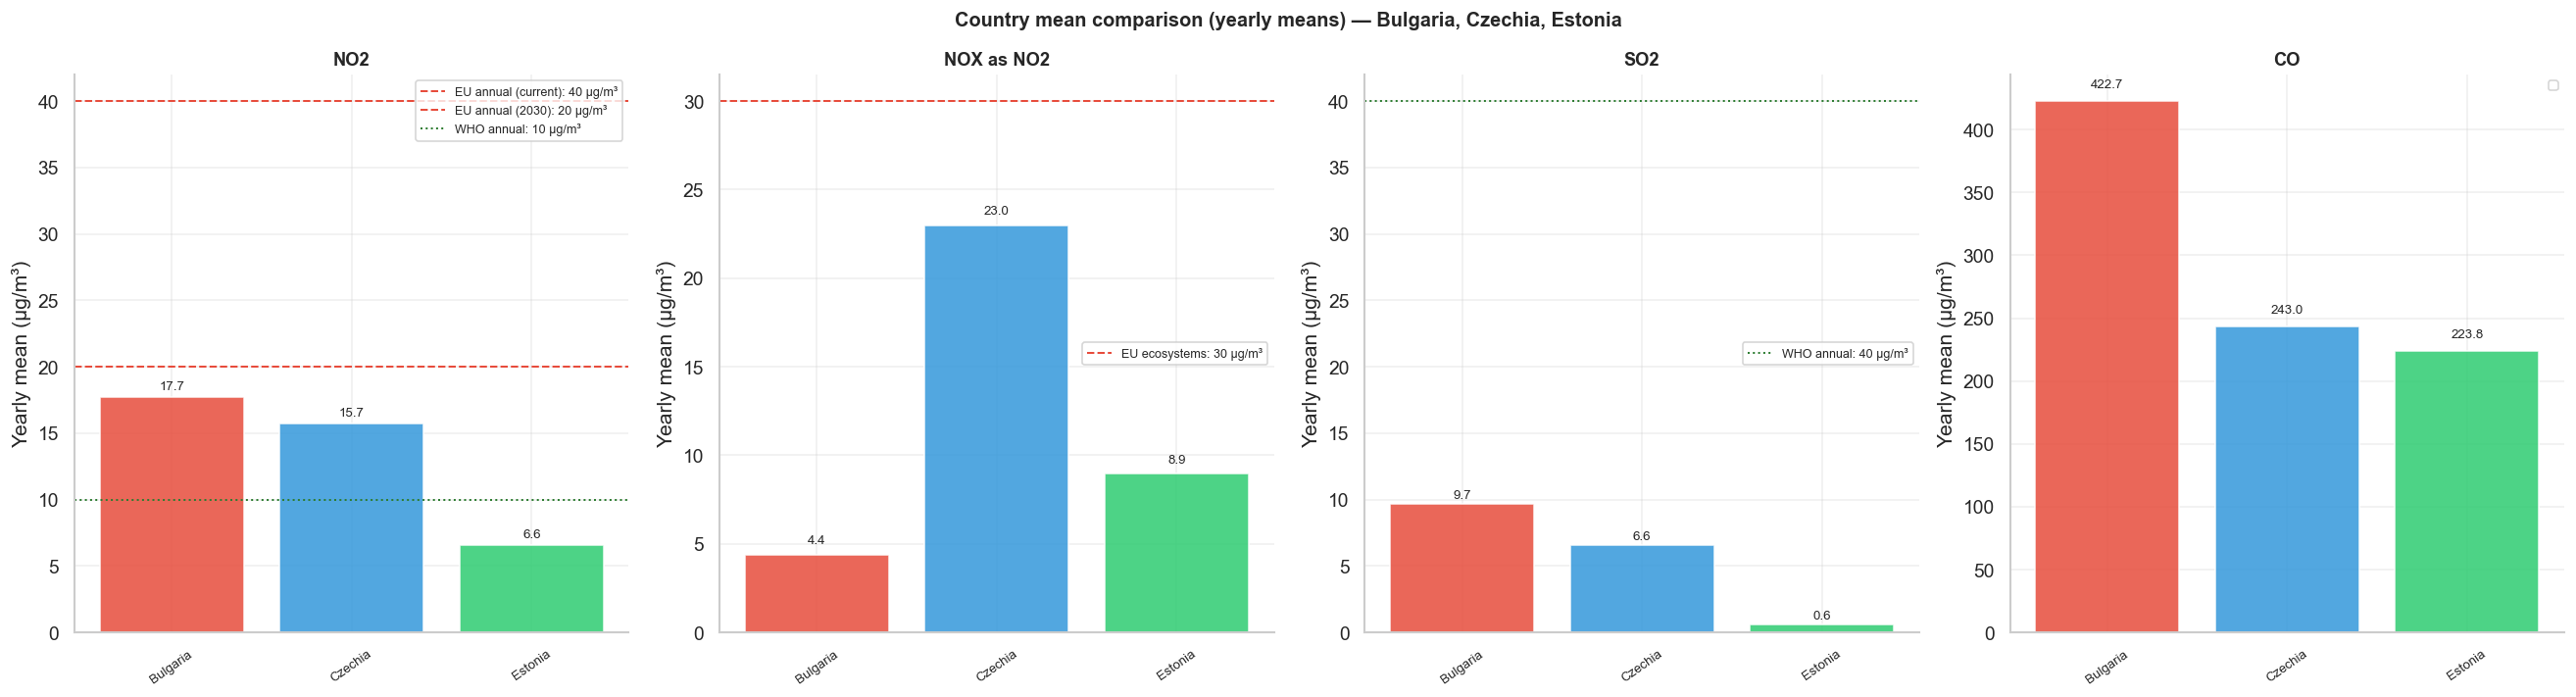

In [22]:
_df    = STATE['df']
_ctrs  = STATE['countries']
_cmap  = country_color_map(_ctrs) if _ctrs else {}
_tag   = '_'.join(_ctrs) if _ctrs else 'no_data'
_title = ', '.join([COUNTRY_NAMES.get(c,c) for c in _ctrs]) if _ctrs else ''

if _df.empty:
    print('No data.')
else:
    polls_p = [p for p in POLLUTANTS if p in _df['pollutant'].unique()]
    # Use yearly means for comparison
    yearly = (_df.groupby(['country','pollutant','year'])['value']
              .mean().reset_index())
    overall = yearly.groupby(['country','pollutant'])['value'].mean().reset_index()

    fig, axes = plt.subplots(1, len(polls_p), figsize=(5.5*len(polls_p), 6))
    if len(polls_p) == 1: axes = [axes]

    for ax, poll in zip(axes, polls_p):
        sub   = overall[overall['pollutant'] == poll].set_index('country')
        means = sub['value'].reindex(_ctrs).round(2)
        bars  = ax.bar(
            [COUNTRY_NAMES.get(c,c) for c in means.index],
            means.values,
            color=[_cmap.get(c,'#95A5A6') for c in means.index],
            alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, means.values):
            if not np.isnan(val):
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+means.max()*0.02,
                        f'{val:.1f}', ha='center', va='bottom', fontsize=8)
        for lname, linfo in LIMITS.get(poll, {}).items():
            if linfo['type'] in ('hourly', '8h', 'daily'):
                continue
            ax.axhline(linfo['value'],
                color='#E74C3C' if linfo['org']=='EU' else '#2E7D32',
                ls='--' if linfo['org']=='EU' else ':',
                lw=1.2, label=f'{lname}: {linfo["value"]} {UNIT}')
        ax.set_title(poll, fontsize=11, fontweight='bold')
        ax.set_ylabel(f'Yearly mean ({UNIT})')
        ax.tick_params(axis='x', rotation=35, labelsize=8)
        if LIMITS.get(poll): ax.legend(fontsize=7.5)

    plt.suptitle(f'Country mean comparison (yearly means) — {_title}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/comparison_{_tag}.png', dpi=150, bbox_inches='tight')
    plt.show()


# Cell 9 - Annual mean by country

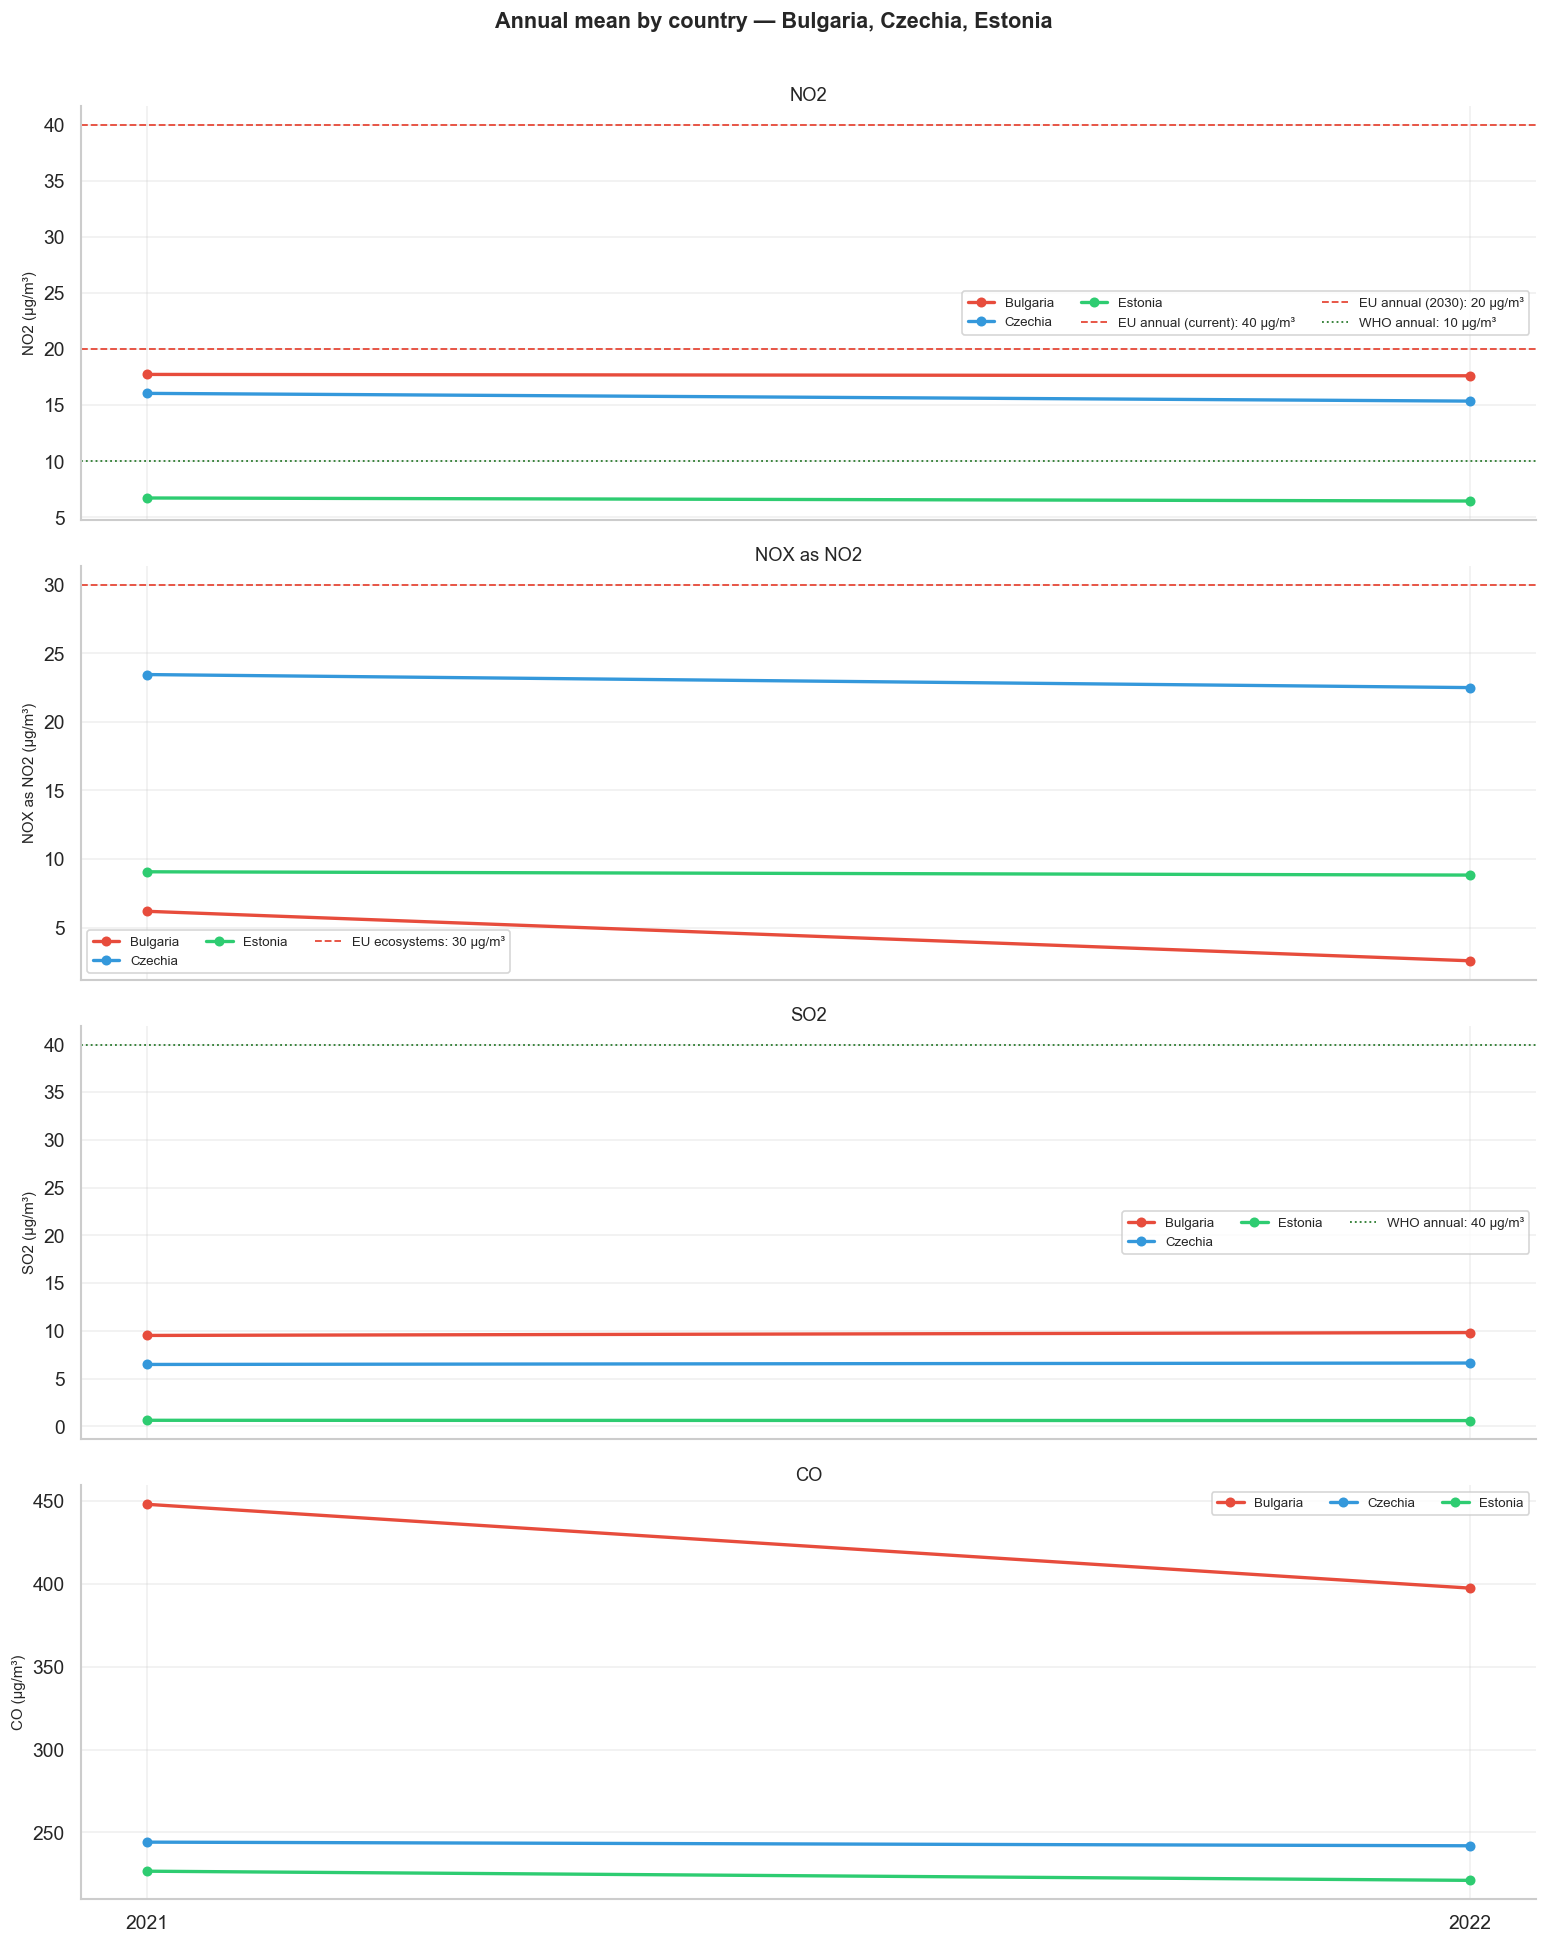

In [23]:
_df    = STATE['df']
_ctrs  = STATE['countries']
_cmap  = country_color_map(_ctrs) if _ctrs else {}
_tag   = '_'.join(_ctrs) if _ctrs else 'no_data'
_title = ', '.join([COUNTRY_NAMES.get(c,c) for c in _ctrs]) if _ctrs else ''

if _df.empty or 'year' not in _df.columns:
    print('No data.')
else:
    polls_p = [p for p in POLLUTANTS if p in _df['pollutant'].unique()]
    fig, axes = plt.subplots(len(polls_p), 1,
                              figsize=(13, 4*len(polls_p)), sharex=True)
    if len(polls_p) == 1: axes = [axes]

    for ax, poll in zip(axes, polls_p):
        for ctr in _ctrs:
            ann = (_df[(_df['pollutant']==poll) & (_df['country']==ctr)]
                   .groupby('year')['value'].mean().round(2))
            if ann.empty: continue
            c = _cmap.get(ctr, '#2C3E50')
            ax.plot(ann.index, ann.values, color=c, lw=2, marker='o',
                    markersize=5, label=COUNTRY_NAMES.get(ctr, ctr))

        for lname, linfo in LIMITS.get(poll, {}).items():
            if linfo['type'] in ('hourly', '8h', 'daily'):
                continue
            if linfo['type'] == 'annual':
                ax.axhline(linfo['value'],
                    color='#E74C3C' if linfo['org']=='EU' else '#2E7D32',
                    ls='--' if linfo['org']=='EU' else ':',
                    lw=1.1, label=f'{lname}: {linfo["value"]} {UNIT}')

        ax.set_ylabel(f'{poll} ({UNIT})', fontsize=9)
        ax.set_title(poll, fontsize=11, pad=3)
        ax.legend(fontsize=8, ncol=min(len(_ctrs), 4))
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    plt.suptitle(f'Annual mean by country — {_title}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/annual_{_tag}.png', dpi=150, bbox_inches='tight')
    plt.show()


# Cell 10 - Monthly heatmap (year × month)

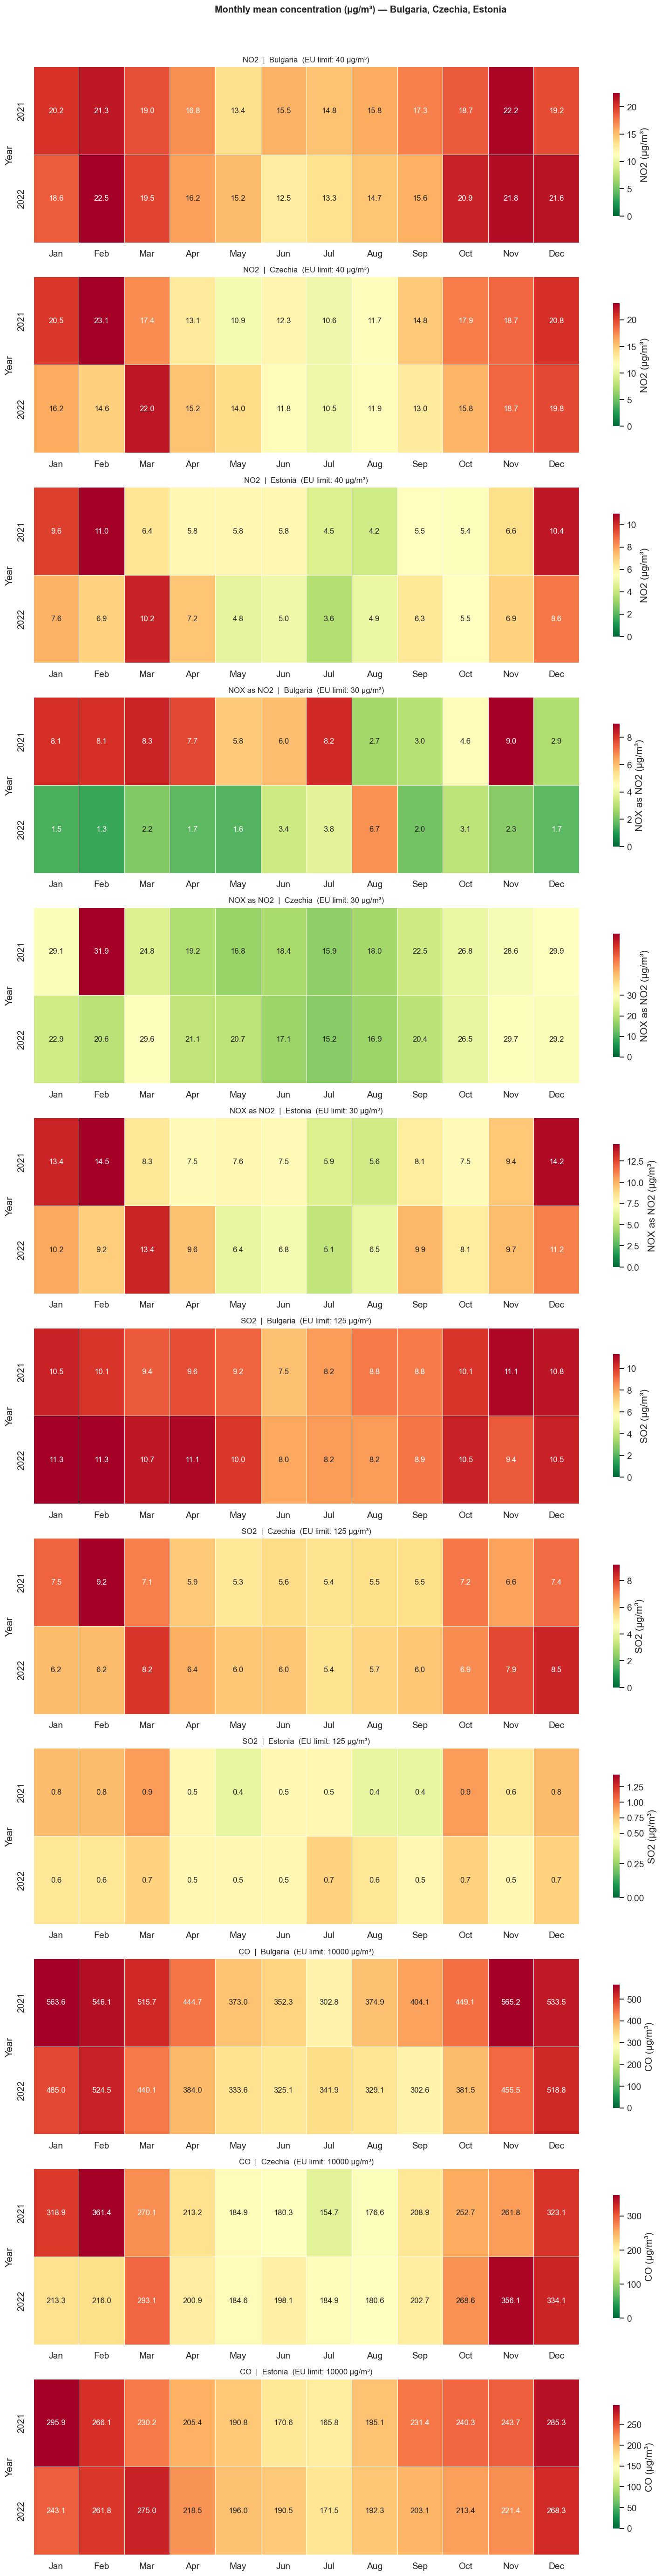

In [24]:
_df    = STATE['df']
_ctrs  = STATE['countries']
_tag   = '_'.join(_ctrs) if _ctrs else 'no_data'
_title = ', '.join([COUNTRY_NAMES.get(c,c) for c in _ctrs]) if _ctrs else ''
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

if _df.empty:
    print('No data.')
else:
    polls_p = [p for p in POLLUTANTS if p in _df['pollutant'].unique()]
    n_total = len(polls_p) * len(_ctrs)
    fig, axes = plt.subplots(n_total, 1, figsize=(13, 3.8*n_total))
    if n_total == 1: axes = [axes]
    af = np.array(axes).flatten(); idx = 0

    for poll in polls_p:
        for ctr in _ctrs:
            ax   = af[idx]; idx += 1
            dfpc = _df[(_df['country']==ctr) & (_df['pollutant']==poll)]
            if dfpc.empty: ax.set_visible(False); continue
            pivot = dfpc.pivot_table(index='year', columns='month',
                                      values='value', aggfunc='mean').round(1)
            pivot.columns = [MONTHS[m-1] for m in pivot.columns]
            # Color relative to EU annual limit:
            #   dark green = well below limit
            #   yellow     = approaching limit
            #   dark red   = above limit
            eu_lim_h = ANNUAL_LIMITS.get(poll, {}).get('EU')
            vmax_h   = pivot.max().max()
            vcenter_h = eu_lim_h if eu_lim_h and eu_lim_h < vmax_h else vmax_h * 0.5
            from matplotlib.colors import TwoSlopeNorm
            norm_h = TwoSlopeNorm(vmin=0, vcenter=vcenter_h, vmax=max(vmax_h, vcenter_h+1))
            sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
                        norm=norm_h,
                        linewidths=0.4, ax=ax,
                        cbar_kws={'label': f'{poll} ({UNIT})', 'shrink': 0.7})
            if eu_lim_h:
                ax.set_title(f'{poll}  |  {COUNTRY_NAMES.get(ctr,ctr)}  '
                             f'(EU limit: {eu_lim_h} {UNIT})', fontsize=10)

            ax.set_xlabel(''); ax.set_ylabel('Year')

    plt.suptitle(f'Monthly mean concentration ({UNIT}) — {_title}',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/heatmap_{_tag}.png', dpi=150, bbox_inches='tight')
    plt.show()


# Cell 11 - Distribution comparison (boxplot of yearly means)

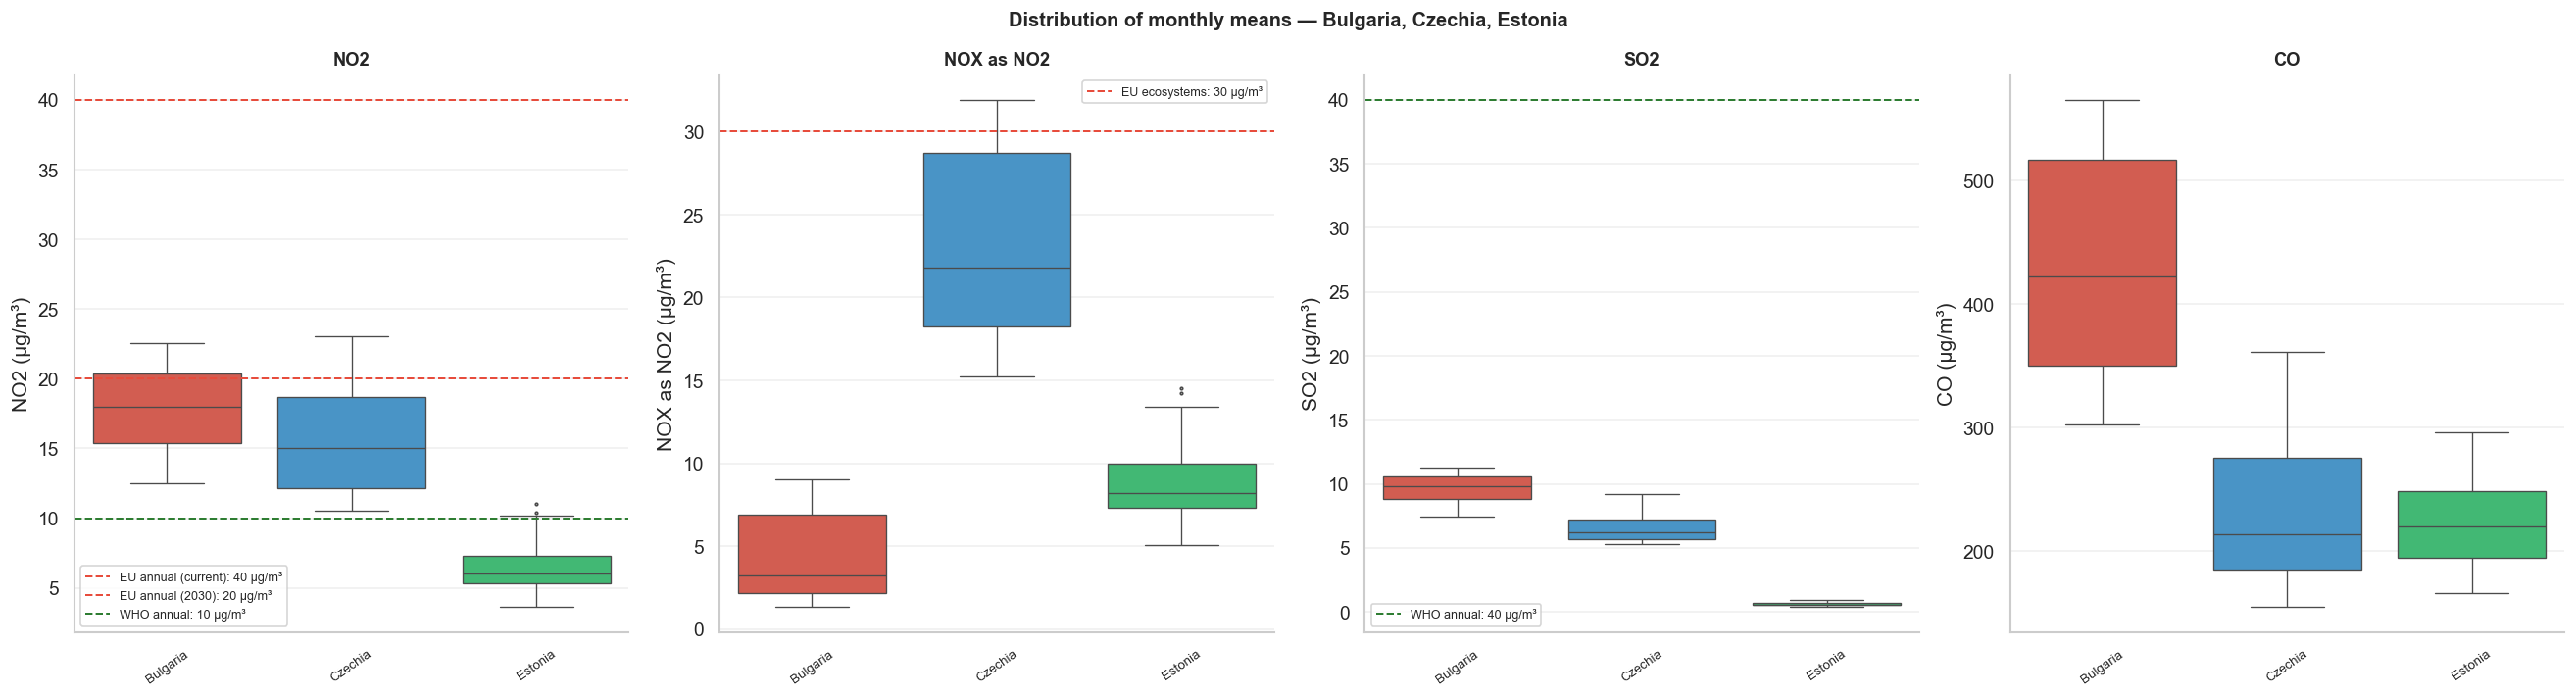

In [25]:
_df    = STATE['df']
_ctrs  = STATE['countries']
_cmap  = country_color_map(_ctrs) if _ctrs else {}
_tag   = '_'.join(_ctrs) if _ctrs else 'no_data'
_title = ', '.join([COUNTRY_NAMES.get(c,c) for c in _ctrs]) if _ctrs else ''

if _df.empty:
    print('No data.')
else:
    polls_p = [p for p in POLLUTANTS if p in _df['pollutant'].unique()]
    order   = sorted(_ctrs, key=lambda c: COUNTRY_NAMES.get(c, c))

    # Box over monthly means for each country
    monthly = (_df[_df['country'].isin(_ctrs)]
               .groupby(['country','pollutant','year','month'])['value']
               .mean().reset_index())

    fig, axes = plt.subplots(1, len(polls_p), figsize=(5.5*len(polls_p), 6))
    if len(polls_p) == 1: axes = [axes]

    for ax, poll in zip(axes, polls_p):
        dfp = monthly[monthly['pollutant'] == poll].copy()
        dfp['Country'] = dfp['country'].map(COUNTRY_NAMES)
        lbl_order = [COUNTRY_NAMES.get(c,c) for c in order]
        palette   = {COUNTRY_NAMES.get(c,c): _cmap[c] for c in order if c in _cmap}
        sns.boxplot(data=dfp, x='Country', y='value', order=lbl_order,
                    palette=palette, linewidth=0.8, fliersize=1.5, ax=ax)
        for lname, linfo in LIMITS.get(poll, {}).items():
            if linfo['type'] in ('hourly', '8h', 'daily'):
                continue
            if linfo['type'] in ('annual','daily','8h'):
                ax.axhline(linfo['value'],
                    color='#E74C3C' if linfo['org']=='EU' else '#2E7D32',
                    ls='--', lw=1.2,
                    label=f'{lname}: {linfo["value"]} {UNIT}')
        ax.set_title(poll, fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel(f'{poll} ({UNIT})')
        ax.tick_params(axis='x', rotation=35, labelsize=8)
        if ax.get_legend_handles_labels()[0]: ax.legend(fontsize=7.5)

    plt.suptitle(f'Distribution of monthly means — {_title}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/boxplot_{_tag}.png', dpi=150, bbox_inches='tight')
    plt.show()


# Cell 12 - Choropleth: annual mean vs limits by country (Plotly)

 How the period selector works:
   - Shows only years actually present in your downloaded data.
   - "All years" = average across every year in STATE['df'].
   - "Last N years" = average across the N most recent years in your data.
   If you downloaded 2020–2022, "Last 3 years" and "All years" give the
   same result. Download more years to see the period comparison work.

 Why only some countries appear:
   Only countries you downloaded are shown. The rest of Europe is grey.

 Colours:
   🟢 Green  = annual mean below WHO guideline
   🟡 Yellow = between WHO and EU current limit
   🔴 Red    = above EU current limit
   ⬜ Grey   = no data downloaded for that country

In [26]:
try:
    import plotly.express as px
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'plotly', '-q'])
    import plotly.express as px

_df   = STATE['df']
_ctrs = STATE['countries']

if _df.empty or 'year' not in _df.columns:
    print('No data. Run Cell 3 and Cell 3b first.')
else:
    _S  = {'description_width': '130px'}
    _LW = widgets.Layout(width='260px')

    all_years   = sorted(_df['year'].dropna().astype(int).unique())
    max_yr      = int(max(all_years))
    min_yr      = int(min(all_years))
    n_yrs_avail = len(all_years)
    polls_avail = sorted(_df['pollutant'].unique())

    # Build period options based on years actually in the data
    period_opts = [('All years', all_years)]
    for n in [5, 4, 3, 2, 1]:
        if n < n_yrs_avail:
            yr_subset = all_years[-n:]
            period_opts.append((f'Last {n} years ({yr_subset[0]}–{yr_subset[-1]})', yr_subset))
    # Most specific first
    period_opts = list(reversed(period_opts))

    poll_w  = widgets.Dropdown(options=polls_avail, value=polls_avail[0],
                                description='Pollutant:', style=_S, layout=_LW)
    period_w = widgets.Dropdown(
        options=[(label, i) for i, (label, _) in enumerate(period_opts)],
        value=0,
        description='Period:', style=_S, layout=_LW)

    info_w = widgets.HTML(
        f'<div style="font-size:11px;background:#e9ecef;border-radius:4px;'
        f'padding:5px 10px;color:#333;margin:4px 0">'
        f'Data available: <b>{min_yr}–{max_yr}</b> ({n_yrs_avail} year{"s" if n_yrs_avail>1 else ""}) | '
        f'Countries: <b>{len(_ctrs)}</b><br>'
        f'Download more years (Cell 3) to enable period comparison.</div>')

    btn = widgets.Button(description='Generate map', button_style='primary',
                          layout=widgets.Layout(width='160px', margin='8px 0 0 0'))
    out = widgets.Output()

    def run_choro(_):
        with out:
            clear_output()
            poll      = poll_w.value
            p_idx     = period_w.value
            yrs_label, yrs_list = period_opts[p_idx]

            sub = _df[(_df['pollutant'] == poll) & (_df['year'].isin(yrs_list))].copy()
            if sub.empty:
                print('No data for this selection.'); return

            # Annual mean per country per year → average across selected years
            ann = sub.groupby(['country', 'year'])['value'].mean().reset_index()
            avg = ann.groupby('country')['value'].mean().reset_index()
            avg.columns    = ['country', 'mean_value']
            avg['mean_value']   = avg['mean_value'].round(2)
            avg['country_name'] = avg['country'].map(COUNTRY_NAMES).fillna(avg['country'])
            avg['iso_a3']       = avg['country'].map(ISO2_TO_ISO3).fillna(avg['country'])

            lim     = ANNUAL_LIMITS.get(poll, {})
            eu_lim  = lim.get('EU')
            who_lim = lim.get('WHO')

            def _cat(v):
                if pd.isna(v): return '⬜ No data'
                if who_lim and eu_lim:
                    if v <= who_lim: return f'🟢 Below WHO ({who_lim} {UNIT})'
                    if v <= eu_lim:  return f'🟡 WHO–EU ({who_lim}–{eu_lim} {UNIT})'
                    return                  f'🔴 Above EU ({eu_lim} {UNIT})'
                if eu_lim:
                    return (f'🟢 Below EU ({eu_lim} {UNIT})' if v <= eu_lim
                            else f'🔴 Above EU ({eu_lim} {UNIT})')
                return '⬜ No annual limit'

            avg['Status'] = avg['mean_value'].apply(_cat)

            if who_lim and eu_lim:
                cat_order = [
                    f'🟢 Below WHO ({who_lim} {UNIT})',
                    f'🟡 WHO–EU ({who_lim}–{eu_lim} {UNIT})',
                    f'🔴 Above EU ({eu_lim} {UNIT})',
                ]
                cmap = {cat_order[0]:'#27AE60', cat_order[1]:'#F1C40F', cat_order[2]:'#E74C3C'}
            elif eu_lim:
                cat_order = [f'🟢 Below EU ({eu_lim} {UNIT})', f'🔴 Above EU ({eu_lim} {UNIT})']
                cmap = {cat_order[0]:'#27AE60', cat_order[1]:'#E74C3C'}
            else:
                cat_order = ['⬜ No annual limit']
                cmap = {cat_order[0]:'#cccccc'}

            ref_txt = (f'WHO: {who_lim} {UNIT} | EU: {eu_lim} {UNIT}'
                       if who_lim and eu_lim else
                       f'EU: {eu_lim} {UNIT}' if eu_lim else 'No annual limit')

            # Show per-year breakdown in hover
            yr_breakdown = (ann.groupby('country')
                              .apply(lambda g: ' | '.join(
                                  [f'{int(r.year)}: {r.value:.1f}'
                                   for _, r in g.sort_values('year').iterrows()]))
                              .reset_index())
            yr_breakdown.columns = ['country', 'by_year']
            avg = avg.merge(yr_breakdown, on='country', how='left')

            avg['hover'] = avg.apply(lambda r:
                f"<b>{r['country_name']}</b><br>"
                f"Mean ({yrs_label}): <b>{r['mean_value']:.2f} {UNIT}</b><br>"
                f"By year: {r['by_year']}<br>"
                f"Status: {r['Status']}",
                axis=1)

            fig = px.choropleth(
                avg,
                locations='iso_a3',
                color='Status',
                color_discrete_map=cmap,
                category_orders={'Status': cat_order},
                hover_name='country_name',
                custom_data=['mean_value', 'Status', 'by_year'],
                scope='europe',
                title=(f'<b>{poll} — {yrs_label}</b><br>'
                       f'<sup>{ref_txt} | Only downloaded countries shown</sup>'),
            )
            fig.update_traces(
                hovertemplate=(
                    f'<b>%{{hovertext}}</b><br>'
                    f'Mean ({yrs_label}): <b>%{{customdata[0]:.2f}} {UNIT}</b><br>'
                    f'By year: %{{customdata[2]}}<br>'
                    f'Status: %{{customdata[1]}}<extra></extra>'
                ))
            fig.update_layout(
                height=580,
                geo=dict(showframe=False, showcoastlines=True,
                         coastlinecolor='#aaa', landcolor='#f0f0f0',
                         showocean=True, oceancolor='#d6eaf8',
                         ),
                legend=dict(title='<b>Status vs limit</b>', x=0.01, y=0.99,
                            bgcolor='rgba(255,255,255,0.85)',
                            bordercolor='#ccc', borderwidth=1),
                margin=dict(l=0, r=0, t=70, b=0))
            fig.show()

            # Ranking table
            tbl = avg[['country_name', 'country', 'mean_value', 'by_year', 'Status']].copy()
            tbl.columns = ['Country', 'Code', f'Mean ({UNIT})', 'By year', 'Status']
            tbl = tbl.sort_values(f'Mean ({UNIT})', ascending=False).reset_index(drop=True)

            def _row_bg(row):
                s = row['Status']
                bg = ('#d5f5e3' if '🟢' in s else
                      '#fef9e7' if '🟡' in s else
                      '#fadbd8' if '🔴' in s else '')
                return [f'background:{bg}' if bg else ''] * len(row)

            display(HTML('<br>'))
            display(tbl.style
                .apply(_row_bg, axis=1)
                .format({f'Mean ({UNIT})': '{:.2f}'})
                .hide(axis='index')
                .set_caption(f'{poll} — ranking ({yrs_label}) | {ref_txt}'))

    btn.on_click(run_choro)
    display(widgets.VBox([
        info_w,
        widgets.HBox([poll_w, period_w]),
        btn, out]))


# Cell 14 - Export data

In [16]:
_tag = '_'.join(STATE['countries']) if STATE['countries'] else 'data'
_S   = {'description_width': '80px'}

path_w = widgets.Text(
    value=f'eea_output/eea_{_tag}_export.csv',
    description='Save to:', style=_S,
    layout=widgets.Layout(width='500px'))
fmt_w = widgets.RadioButtons(
    options=[('CSV','.csv'),('Parquet','.parquet')],
    value='.csv', description='Format:', style=_S)
btn   = widgets.Button(description='Export', button_style='success',
                        layout=widgets.Layout(width='130px', margin='8px 0 0 0'))
out   = widgets.Output()

def on_export(_):
    with out:
        clear_output()
        df_exp = STATE['df']
        if df_exp.empty: print('No data to export.'); return
        path = path_w.value
        os.makedirs(os.path.dirname(path) or '.', exist_ok=True)
        if fmt_w.value == '.csv':
            df_exp.to_csv(path, index=False)
        else:
            df_exp.to_parquet(path, index=False)
        print('=' * 50)
        print('  Export complete')
        print('-' * 50)
        print(f'  Rows    : {len(df_exp):,}')
        print(f'  Unit    : {UNIT}')
        print(f'  Period  : {STATE["y0"]}–{STATE["y1"]}')
        print(f'  Dataset : {STATE["dataset"]}')
        print(f'  Saved   : {path}')
        print('=' * 50)

btn.on_click(on_export)
display(widgets.HBox([fmt_w, path_w]))
display(btn, out)


Button(button_style='success', description='Export', layout=Layout(margin='8px 0 0 0', width='130px'), style=B…

Output()